In [1]:
# Let's add the root directory to our system search path to allow imports from sibling directories.
import os, sys
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

LOG_DIR = Path("../logs/")
LOG_FILES = sorted(Path("../logs").glob("*.log"))

In [3]:
def get_log_data():
    data = {
        "epochs": [],
        "lr": [],
        "temp": [],
        "m": [],
        "wd": [],
        "dino": [],
        "ibot": [],
        "hsic": [],
        "koleo": []
    }

    for log in LOG_FILES:
        lines = None
        with open(log, 'r') as f:
            lines = f.readlines()

        for i, line in enumerate(lines):
            if "Epoch" not in line:
                continue
            elif "[0000/" in line:
                data["epochs"].append(i)

            l = line.split("lr: ")[-1]
            l = l.split(',')

            lr = float(l[0])
            data["lr"].append(lr)

            temp = float(l[1].split(': ')[-1])
            data["temp"].append(temp)

            m = float(l[2].split(': ')[-1])
            data["m"].append(m)

            dino = float(l[3].split(': ')[-1])
            data["dino"].append(dino)

            ibot = float(l[4].split(': ')[-1])
            data["ibot"].append(ibot)

            hsic = float(l[5].split(': ')[-1])
            data["hsic"].append(hsic)

            koleo = float(l[6].split(': ')[-1])
            data["koleo"].append(koleo)

    return data


def show_figure(graphs, labels, name, epochs=None, threshold=None):
    plt.figure(figsize=(12, 6))

    # Determine x-axis: Use epoch mapping if provided, otherwise default to iterations
    if epochs is not None:
        iters = np.linspace(0, len(epochs), len(graphs[0]))
        xlabel = 'Epochs'
    else:
        iters = range(len(graphs[0]))
        xlabel = 'Iterations'

    # Draw a dotted red line at threshold
    if threshold is not None:
        plt.axhline(y=threshold, color='red', linestyle=':')

    # Plot data
    for i in range(len(graphs)):
        plt.plot(iters, graphs[i], label=labels[i])

    # Add labels and title
    plt.title(name)
    plt.xlabel(xlabel)
    plt.ylabel('Values')
    plt.legend()
    plt.grid()

    # Show the plot
    plt.show()

In [4]:
log_data = get_log_data()

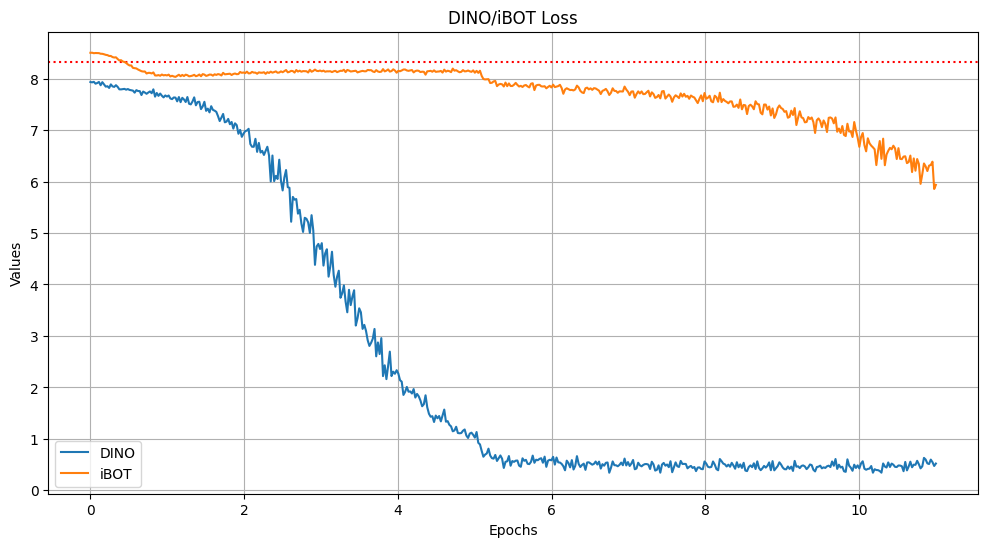

In [5]:
show_figure((log_data['dino'], log_data['ibot']), ('DINO', 'iBOT'), "DINO/iBOT Loss", epochs=log_data["epochs"], threshold=np.log(4096))

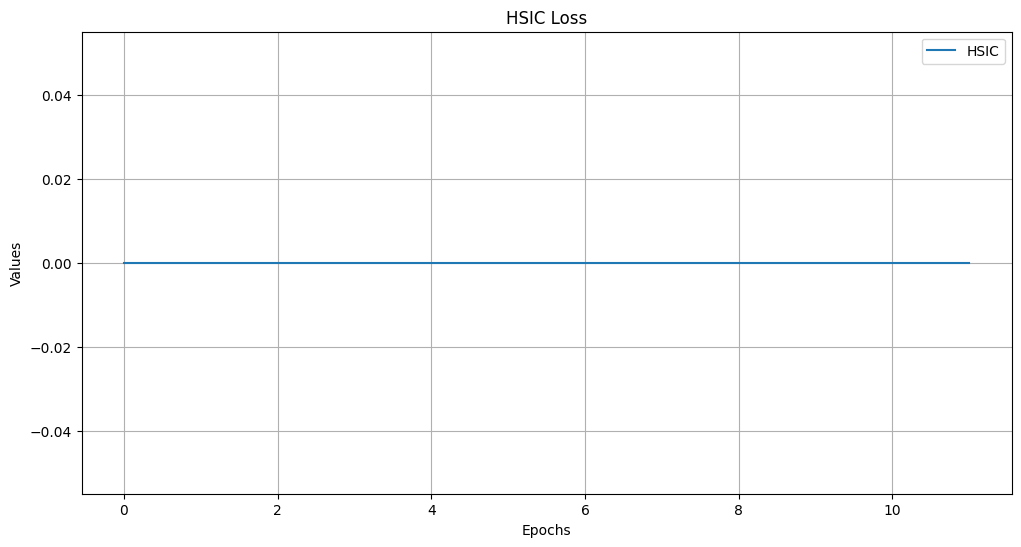

In [6]:
show_figure((log_data['hsic'],), ('HSIC',), "HSIC Loss", epochs=log_data["epochs"])

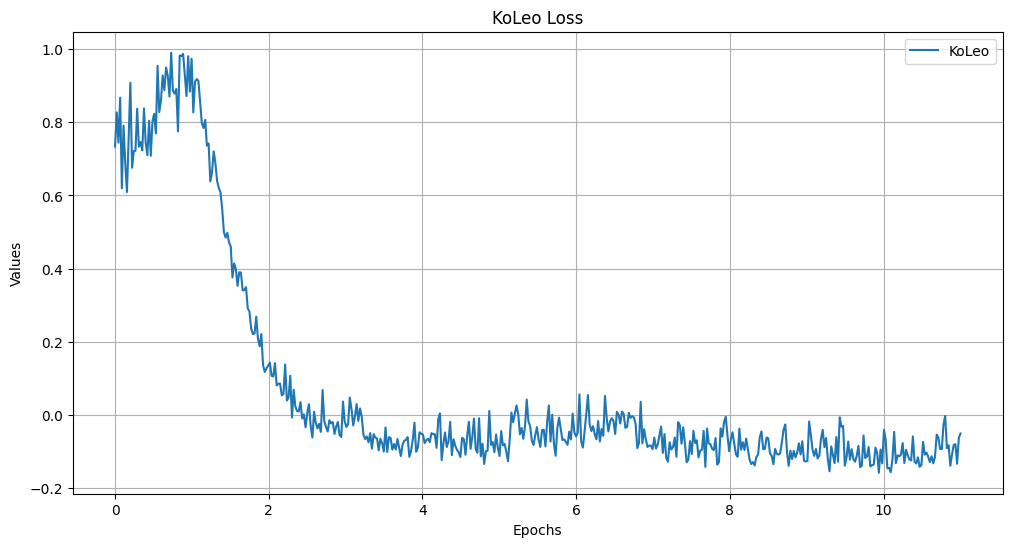

In [7]:
show_figure((log_data['koleo'],), ('KoLeo',), "KoLeo Loss", epochs=log_data["epochs"])
